This notetook aims at training and testing the VGG16 neural network for an image classification task. It includes:
- Construct the vanilla VGG16 model, named VGG16-version1, from scratch by sequentially defining each layer to accomplish the image classification task.
- Enhance the VGG16 model by adding supplementary layers of your choice to boost the performance of VGG16-version1, now designated as VGG16-version2.




## VGG16 architecture

![alt text](VGG16-architecture-1.png)

![alt text](VGG16-architecture-2.png)

Some characteristics of the VGG16 architecture:
- Kernel size of all convolutional layers is 3x3.
- Numbers of filters of every block are sequentially 64, 128, 256, 512, 512 as in the figure.
- All activation functions are ReLUs, except the output layer which uses softmax.
- Dropout probability used after dense layers is 0.5.

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset

In [ ]:
# Load the MNIST dataset and split train/test
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


# Normalize and resize the image

In [ ]:
# Normalize data to the value range [0,1]
X_train, X_test = X_train/255.0, X_test/255.0

In [ ]:
# Show shape of the training and test data
print("Train shape: X_train = " + str(X_train.shape) + ", y_train = " + str(y_train.shape))
print("Test shape: X_test = " + str(X_test.shape) + ", y_test = " + str(y_test.shape))

Train shape: X_train = (60000, 28, 28), y_train = (60000,)
Test shape: X_test = (10000, 28, 28), y_test = (10000,)


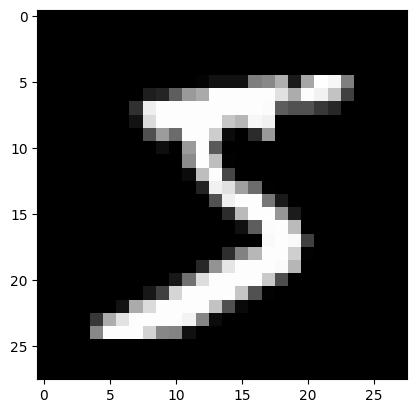

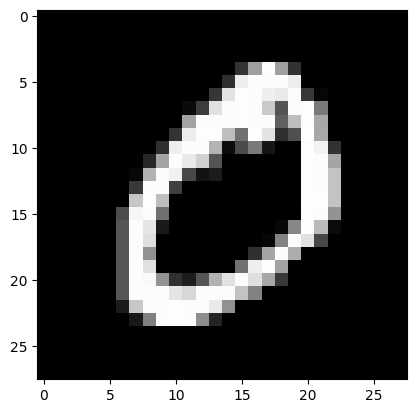

In [ ]:
# Show an image
for i in range(2):
    plt.imshow(X_train[i,:,:], cmap='gray')
    plt.show()

In [ ]:
y_train[0:2]

array([5, 0], dtype=uint8)

In [ ]:
print("Train shape: X_train = " + str(X_train.shape) + ", y_train = " + str(y_train.shape))
print("Test shape: X_test = " + str(X_test.shape) + ", y_test = " + str(y_test.shape))

Train shape: X_train = (60000, 28, 28), y_train = (60000,)
Test shape: X_test = (10000, 28, 28), y_test = (10000,)


In [ ]:
from tensorflow.image import resize

In [ ]:
# Expand the grayscale images to 3 channels (RGB)
X_train = np.repeat(X_train[..., np.newaxis], 3, -1)
X_test = np.repeat(X_test[..., np.newaxis], 3, -1)
# Resize images to 224x224
X_train = np.array([resize(image, (32, 32)).numpy() for image in X_train])
X_test = np.array([resize(image, (32, 32)).numpy() for image in X_test])

In [ ]:
print("Train shape: X_train = " + str(X_train.shape) + ", y_train = " + str(y_train.shape))
print("Test shape: X_test = " + str(X_test.shape) + ", y_test = " + str(y_test.shape))

Train shape: X_train = (60000, 32, 32, 3), y_train = (60000,)
Test shape: X_test = (10000, 32, 32, 3), y_test = (10000,)


In [ ]:
# Split the train/valid from the training set
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state =5)

In [ ]:
print("Train shape: X_train = " + str(X_train.shape), " y_train = " +str(y_train.shape))
print("Test shape: X_test = " + str(X_test.shape), " y_test = " +str(y_test.shape))
print("Validation shape: X_val = " + str(X_val.shape), " y_val = " +str(y_val.shape))

Train shape: X_train = (54000, 32, 32, 3)  y_train = (54000,)
Test shape: X_test = (10000, 32, 32, 3)  y_test = (10000,)
Validation shape: X_val = (6000, 32, 32, 3)  y_val = (6000,)


# Build VGG16-version1

**`Model architecture`**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization

In [ ]:
VGG16= Sequential(name='VGG16')

#Block 1
VGG16.add(Conv2D(filters=64, input_shape=(32,32,3), kernel_size=(3,3), activation='relu', padding='same', name='Block_1_Conv'))
VGG16.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'))
VGG16.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='same', name='Block_1_MaxPool'))

# Block 2
VGG16.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same', name='Block_2_Conv'))
VGG16.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'))
VGG16.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='same', name='Block_2_MaxPool'))

# Block 3
VGG16.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same', name='Block_3_Conv'))
VGG16.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same'))
VGG16.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same'))
VGG16.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='same', name='Block_3_MaxPool'))

# Block 4
VGG16.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same', name='Block_4_Conv'))
VGG16.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same'))
VGG16.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same'))
VGG16.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='same', name='Block_4_MaxPool'))

# Block 5
VGG16.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same', name='Block_5_Conv'))
VGG16.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same'))
VGG16.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same'))
VGG16.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='same', name='Block_5_MaxPool'))

# Flatten
VGG16.add(Flatten())
# Fully connected layers
VGG16.add(Dense(4096))
VGG16.add(Activation('relu'))
VGG16.add(Dense(4096))
VGG16.add(Activation('relu'))
VGG16.add(Dense(10))
VGG16.add(Activation('softmax'))
VGG16.add(Dropout(rate=0.5))

In [ ]:
VGG16.summary()

Model: "VGG16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Block_1_Conv (Conv2D)       (None, 32, 32, 64)        1792      
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 64)        36928     
                                                                 
 Block_1_MaxPool (MaxPoolin  (None, 16, 16, 64)        0         
 g2D)                                                            
                                                                 
 Block_2_Conv (Conv2D)       (None, 16, 16, 128)       73856     
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 128)       147584    
                                                                 
 Block_2_MaxPool (MaxPoolin  (None, 8, 8, 128)         0         
 g2D)                                                        

In [ ]:
# Compile the model
VGG16.compile(loss = tf.keras.losses.sparse_categorical_crossentropy, # Define loss function
                optimizer= tf.keras.optimizers.Adam(learning_rate=5e-5), metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
mc = ModelCheckpoint(filepath="epoch-{epoch:02d}.keras",monitor='val_loss',mode='min',verbose=0, save_best_only=True)

# Train VGG16-version1

In [ ]:
history = VGG16.fit(X_train, y_train, batch_size=128, epochs=10, validation_data=(X_val, y_val), callbacks=[mc])

Epoch 1/10
422/422 [==============================] - 242s 567ms/step - loss: 7.2476 - accuracy: 0.1858 - val_loss: 4.6089 - val_accuracy: 0.3912
Epoch 2/10
422/422 [==============================] - 235s 558ms/step - loss: 4.9213 - accuracy: 0.3317 - val_loss: 2.0812 - val_accuracy: 0.8073
Epoch 3/10
422/422 [==============================] - 238s 563ms/step - loss: 2.4226 - accuracy: 0.4655 - val_loss: 1.1118 - val_accuracy: 0.9203
Epoch 4/10
422/422 [==============================] - 236s 559ms/step - loss: 1.8097 - accuracy: 0.4999 - val_loss: 1.3433 - val_accuracy: 0.9010
Epoch 5/10
422/422 [==============================] - 237s 561ms/step - loss: 1.7282 - accuracy: 0.4961 - val_loss: 0.9849 - val_accuracy: 0.9325
Epoch 6/10
422/422 [==============================] - 237s 561ms/step - loss: 1.6557 - accuracy: 0.5073 - val_loss: 0.7250 - val_accuracy: 0.9507
Epoch 7/10
422/422 [==============================] - 237s 561ms/step - loss: 1.5682 - accuracy: 0.5019 - val_loss: 0.5693 -

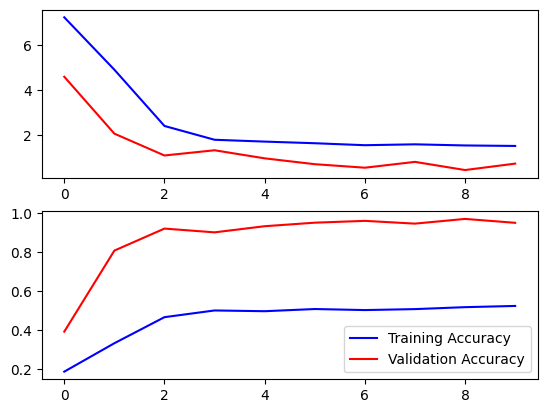

In [ ]:
# Visualize training and validation performance
f,ax=plt.subplots(2,1)

# Plot training and validation loss
ax[0].plot(history.history['loss'], color='b',label='Training Loss')
ax[0].plot(history.history['val_loss'],color='r',label='Validation Loss')

# Plot training and validation accuracy
ax[1].plot(history.history['accuracy'],color='b',label='Training Accuracy')
ax[1].plot(history.history['val_accuracy'],color='r',label='Validation Accuracy')

plt.legend()

In [ ]:
result = VGG16.evaluate(X_test, y_test)
print(VGG16.metrics_names)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result[0],result[1]))

313/313 [==============================] - 13s 40ms/step - loss: 0.7031 - accuracy: 0.9541
['loss', 'accuracy']
Loss and accuracy on the test set: loss = 0.7030733227729797, accuracy = 0.9541000127792358


# VGG16-version2

In [ ]:
VGG16_ver2= Sequential(name='VGG16-version2')

#Block 1
VGG16_ver2.add(Conv2D(filters=64, input_shape=(32,32,3), kernel_size=(3,3), activation='relu', padding='same', name='Block_1_Conv'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='same', name='Block_1_MaxPool'))

# Block 2
VGG16_ver2.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same', name='Block_2_Conv'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='same', name='Block_2_MaxPool'))

# Block 3
VGG16_ver2.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same', name='Block_3_Conv'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='same', name='Block_3_MaxPool'))

# Block 4
VGG16_ver2.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same', name='Block_4_Conv'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='same', name='Block_4_MaxPool'))

# Block 5
VGG16_ver2.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same', name='Block_5_Conv'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same'))
VGG16_ver2.add(BatchNormalization())
VGG16_ver2.add(MaxPooling2D(pool_size=(3,3), strides=(2,2), padding='same', name='Block_5_MaxPool'))

# Flatten
VGG16_ver2.add(Flatten())
# Fully connected layers
VGG16_ver2.add(Dense(4096))
VGG16_ver2.add(Activation('relu'))
VGG16_ver2.add(Dropout(rate=0.5))
VGG16_ver2.add(Dense(4096))
VGG16_ver2.add(Activation('relu'))
VGG16_ver2.add(Dropout(rate=0.5))
VGG16_ver2.add(Dense(10))
VGG16_ver2.add(Activation('softmax'))
VGG16_ver2.add(Dropout(rate=0.5))

In [ ]:
VGG16_ver2.summary()

Model: "VGG16-version2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Block_1_Conv (Conv2D)       (None, 32, 32, 64)        1792      
                                                                 
 batch_normalization (Batch  (None, 32, 32, 64)        256       
 Normalization)                                                  
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 64)        36928     
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 64)        256       
 chNormalization)                                                
                                                                 
 Block_1_MaxPool (MaxPoolin  (None, 16, 16, 64)        0         
 g2D)                                                            
                                                    

In [ ]:
# Compile the model
VGG16_ver2.compile(loss = tf.keras.losses.sparse_categorical_crossentropy, # Define loss function
                optimizer= tf.keras.optimizers.Adam(learning_rate=5e-5), metrics=['accuracy'])

In [ ]:
from keras.callbacks import ReduceLROnPlateau
from keras.regularizers import l2
from keras.callbacks import EarlyStopping

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)
early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)

In [ ]:
history_2 = VGG16_ver2.fit(X_train, y_train, batch_size=128, epochs=30, validation_data=(X_val, y_val), callbacks=[mc,reduce_lr, early_stopping])

Epoch 1/30
422/422 [==============================] - 297s 694ms/step - loss: 2.7610 - accuracy: 0.4419 - val_loss: 10.8035 - val_accuracy: 0.1790 - lr: 5.0000e-05
Epoch 2/30
422/422 [==============================] - 290s 686ms/step - loss: 1.3778 - accuracy: 0.4905 - val_loss: 0.4474 - val_accuracy: 0.9622 - lr: 5.0000e-05
Epoch 3/30
422/422 [==============================] - 290s 687ms/step - loss: 1.3458 - accuracy: 0.5045 - val_loss: 0.4247 - val_accuracy: 0.9662 - lr: 5.0000e-05
Epoch 4/30
422/422 [==============================] - 285s 676ms/step - loss: 1.3512 - accuracy: 0.5108 - val_loss: 0.3885 - val_accuracy: 0.9697 - lr: 5.0000e-05
Epoch 5/30
422/422 [==============================] - 283s 671ms/step - loss: 1.3248 - accuracy: 0.5259 - val_loss: 1.0359 - val_accuracy: 0.9235 - lr: 5.0000e-05
Epoch 6/30
422/422 [==============================] - 284s 672ms/step - loss: 1.3432 - accuracy: 0.5264 - val_loss: 0.4139 - val_accuracy: 0.9685 - lr: 5.0000e-05
Epoch 7/30
422/422 [=

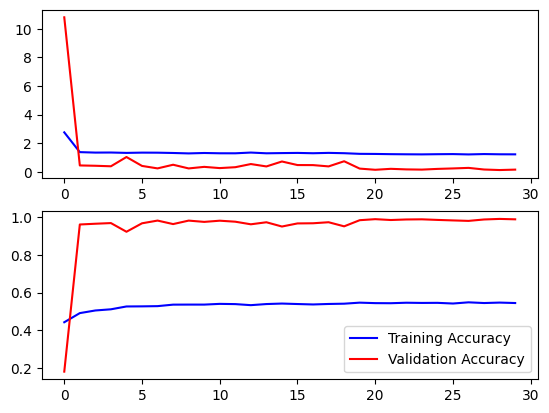

In [ ]:
# Visualize training and validation performance
f,ax=plt.subplots(2,1)

# Plot training and validation loss
ax[0].plot(history_2.history['loss'], color='b',label='Training Loss')
ax[0].plot(history_2.history['val_loss'],color='r',label='Validation Loss')

# Plot training and validation accuracy
ax[1].plot(history_2.history['accuracy'],color='b',label='Training Accuracy')
ax[1].plot(history_2.history['val_accuracy'],color='r',label='Validation Accuracy')

plt.legend()

In [ ]:
result_2 = VGG16_ver2.evaluate(X_test, y_test)
print(VGG16_ver2.metrics_names)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result_2[0],result_2[1]))

313/313 [==============================] - 15s 49ms/step - loss: 0.1763 - accuracy: 0.9883
['loss', 'accuracy']
Loss and accuracy on the test set: loss = 0.17627789080142975, accuracy = 0.9883000254631042


In version 2, I added BatchNormalization after every Conv2D layer to stabilize and speed up training by normalizing the activations of each layer as well as dropout layer to prevent overfitting

* Accuracy Improvement: the accuracy jump from 0.9541 to 0.9883 shows that the network is better able to classify images accurately. This may due to the combination of Batch Normalization for more stable and faster learning and Dropout for regularization allowed the model to better generalize, avoid overfitting and learn more effectively, leading to performance boost.
* Overvation: High Validation Accuracy but Low Training Accuracy. It suggests the model is well-regularized, but potentially too much, making it perform worse on training data
* Future improvement: training for more epochs might help the model learn better representations, potentially increasing training accuracy